In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import sklearn as sk

In [5]:
import matplotlib.pyplot as plt

In [6]:
from datetime import datetime

In [7]:
import requests

In [86]:
from sklearn.preprocessing import PowerTransformer

## Fetch The previous 2 Year Data Using Open Meteo, Api!

In [8]:
# def get_historical_data():
    
#     end_date = "2026-01-28"
#     start_date = "2024-01-30"
    
    
#     aq_url = "https://air-quality-api.open-meteo.com/v1/air-quality"
#     aq_params = {
#         "latitude": 24.8607,
#         "longitude": 67.0011,
#         "hourly": "pm2_5,pm10",
#         "start_date": start_date,
#         "end_date": end_date,
#         "timezone": "auto"
#     }
    
    
#     weather_url = "https://archive-api.open-meteo.com/v1/archive"
#     weather_params = {
#         "latitude": 24.8607,
#         "longitude": 67.0011,
#         "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m",
#         "start_date": start_date,
#         "end_date": end_date,
#         "timezone": "auto"
#     }
    
#     aq_resp = requests.get(aq_url, params=aq_params).json()
#     weather_resp = requests.get(weather_url, params=weather_params).json()

#     df_aq = pd.DataFrame(aq_resp["hourly"])
#     df_weather = pd.DataFrame(weather_resp["hourly"])
    
#     # We merge the weather and AQI 
#     df = pd.merge(df_aq, df_weather, on="time")
#     df['city'] = 'karachi'
#     df['time'] = pd.to_datetime(df['time'])
#     df.to_csv("karachi_dataset.csv", index = False)
#     return df

# # karachi_df = get_historical_data()

In [9]:
df = pd.read_csv("karachi_dataset.csv")

# Cleaning the data

In [10]:
df.head()

,time,pm2_5,pm10,temperature_2m,relative_humidity_2m,wind_speed_10m,city
0,2024-01-30 00:00:00,23.2,46.8,20.4,94,5.2,karachi
1,2024-01-30 01:00:00,23.8,48.0,20.1,95,4.7,karachi
2,2024-01-30 02:00:00,24.4,49.9,20.9,92,1.3,karachi
3,2024-01-30 03:00:00,24.2,50.6,20.7,92,1.8,karachi
4,2024-01-30 04:00:00,24.7,53.0,20.6,92,2.5,karachi


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time                  17520 non-null  object 
 1   pm2_5                 17520 non-null  float64
 2   pm10                  17520 non-null  float64
 3   temperature_2m        17520 non-null  float64
 4   relative_humidity_2m  17520 non-null  int64  
 5   wind_speed_10m        17520 non-null  float64
 6   city                  17520 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 958.3+ KB


In [12]:
df["time"] = pd.to_datetime(df["time"])

## Change Data Type of Time From object to datatime (data type)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  17520 non-null  datetime64[ns]
 1   pm2_5                 17520 non-null  float64       
 2   pm10                  17520 non-null  float64       
 3   temperature_2m        17520 non-null  float64       
 4   relative_humidity_2m  17520 non-null  int64         
 5   wind_speed_10m        17520 non-null  float64       
 6   city                  17520 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 958.3+ KB


In [14]:
df.head()

,time,pm2_5,pm10,temperature_2m,relative_humidity_2m,wind_speed_10m,city
0,2024-01-30 00:00:00,23.2,46.8,20.4,94,5.2,karachi
1,2024-01-30 01:00:00,23.8,48.0,20.1,95,4.7,karachi
2,2024-01-30 02:00:00,24.4,49.9,20.9,92,1.3,karachi
3,2024-01-30 03:00:00,24.2,50.6,20.7,92,1.8,karachi
4,2024-01-30 04:00:00,24.7,53.0,20.6,92,2.5,karachi


## Creating a feature Using Time (Hour, Day, Week)

In [15]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek

In [16]:
df.drop("year",axis = 1, inplace = True)

In [17]:
df.drop("day_of_week",axis = 1, inplace = True)

In [18]:
df.head()

,time,pm2_5,pm10,temperature_2m,relative_humidity_2m,wind_speed_10m,city,month,day,hour
0,2024-01-30 00:00:00,23.2,46.8,20.4,94,5.2,karachi,1,30,0
1,2024-01-30 01:00:00,23.8,48.0,20.1,95,4.7,karachi,1,30,1
2,2024-01-30 02:00:00,24.4,49.9,20.9,92,1.3,karachi,1,30,2
3,2024-01-30 03:00:00,24.2,50.6,20.7,92,1.8,karachi,1,30,3
4,2024-01-30 04:00:00,24.7,53.0,20.6,92,2.5,karachi,1,30,4


In [19]:
df.isnull().sum()

time                    0
pm2_5                   0
pm10                    0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
city                    0
month                   0
day                     0
hour                    0
dtype: int64

# No Null values in the  AQI Data

In [20]:
df.describe()

,time,pm2_5,pm10,temperature_2m,relative_humidity_2m,wind_speed_10m,month,day,hour
count,17520,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000,17520.000000
mean,2025-01-28 23:30:00,27.651804,60.379715,26.656884,64.063527,13.167255,6.527397,15.720548,11.500000
min,2024-01-30 00:00:00,3.800000,3.900000,9.200000,5.000000,0.000000,1.000000,1.000000,0.000000
25%,2024-07-30 11:45:00,18.900000,37.800000,23.800000,49.000000,8.200000,4.000000,8.000000,5.750000
50%,2025-01-28 23:30:00,24.500000,51.500000,27.500000,69.000000,11.900000,7.000000,16.000000,11.500000
75%,2025-07-30 11:15:00,33.100000,72.400000,30.000000,82.000000,17.000000,10.000000,23.000000,17.250000
max,2026-01-28 23:00:00,108.700000,448.900000,41.500000,100.000000,46.600000,12.000000,31.000000,23.000000
std,NaN,12.823848,36.850146,4.925972,22.015396,6.728801,3.445952,8.796498,6.922384


<h4>The dataset shows generally moderate air pollution levels in Karachi, with average PM2.5 around 28 and PM10 around 60, indicating regular exposure to dust and urban pollution, with occasional extreme spikes likely caused by dust storms or unusual events. The weather profile reflects a typical coastal climate, with warm average temperatures around 26–27°C, relatively high humidity near 64%, and moderate wind speeds that can help disperse pollutants. Overall, the data appears well distributed across time and captures realistic seasonal and environmental variations, making it suitable for air quality analysis and model training.<h4>

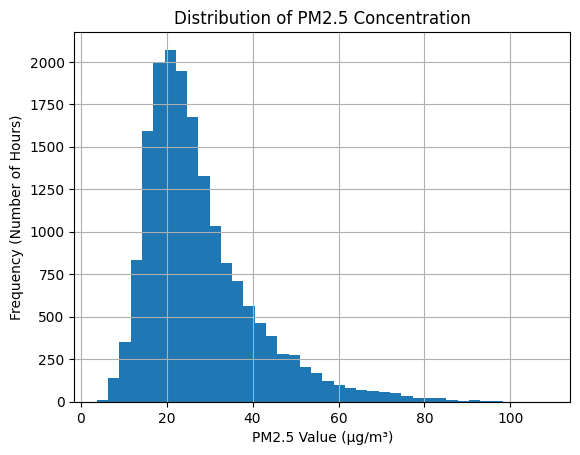

In [21]:
plt.figure()
df["pm2_5"].hist(bins=40)

plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 Value (µg/m³)")
plt.ylabel("Frequency (Number of Hours)")

plt.show()

## The distribution graph of PM2.5 shows how many hours of data fall into each pollution range, with taller bars meaning more hours recorded at that concentration level.

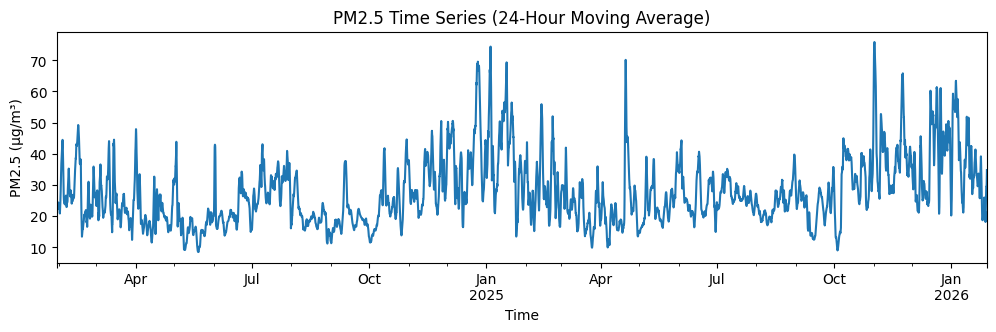

In [22]:
plt.figure(figsize=(12, 3))

df.set_index("time")["pm2_5"].rolling(24).mean().plot()

plt.title("PM2.5 Time Series (24-Hour Moving Average)")
plt.xlabel("Time")
plt.ylabel("PM2.5 (µg/m³)")

plt.show()

## Spikes Shows The Pm2.5, It represent the pollution

In [23]:
print("Start Date:", df["time"].min())
print("End Date:", df["time"].max())

Start Date: 2024-01-30 00:00:00
End Date: 2026-01-28 23:00:00


In [24]:
time_diff = df["time"].sort_values().diff().value_counts()

In [25]:
print("\nTime Difference Counts:")
print(time_diff.head())


Time Difference Counts:
time
0 days 01:00:00    17519
Name: count, dtype: int64


## This shows that the data set is on Hourly bases 

In [26]:
gaps = df["time"].sort_values().diff()

In [27]:
missing_hours = gaps[gaps > pd.Timedelta(hours=1)]

In [28]:
print("\nNumber of Missing Time Gaps:", len(missing_hours))


Number of Missing Time Gaps: 0


In [29]:
if len(missing_hours) > 0:
    print("\nSample Gaps:")
    print(missing_hours.head())
else:
    print("\n No Major Time Gaps Found")


 No Major Time Gaps Found


## No Gap Gaps Found in Times Column

In [30]:
duplicates = df.duplicated().sum()
print(f"Duplicate Rows Found: {duplicates}")

Duplicate Rows Found: 0


## No Duplicatio  In the Data Set

In [31]:
pollutant_cols = ["pm2_5", "pm10"] 

In [32]:
for col in pollutant_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        print(f"{col} Negative Values: {neg_count}")
    else:
        print(f"{col} Column Not Found - Please Adjust Name")

pm2_5 Negative Values: 0
pm10 Negative Values: 0


In [33]:
weather_ranges = {
    "temperature_2m": (-50, 60),        # Celsius realistic earth range
    "relative_humidity_2m": (0, 100),   # %
    "wind_speed_10m": (0, 150)          # km/h safe upper extreme
}

In [34]:
for col, (min_val, max_val) in weather_ranges.items():
    if col in df.columns:
        bad_vals = df[(df[col] < min_val) | (df[col] > max_val)]
        print(f"{col} Impossible Values Count: {len(bad_vals)}")
    else:
        print(f"{col} Not Found ")

temperature_2m Impossible Values Count: 0
relative_humidity_2m Impossible Values Count: 0
wind_speed_10m Impossible Values Count: 0


## There  is no Impossible value in the table

In [35]:
if "relative_humidity_2m" in df.columns:
    hum_max = df["relative_humidity_2m"].max()
    print(f"Humidity Max Value: {hum_max}")
    if hum_max <= 1:
        print("Humidity is in a fraction (0-1)")
    else:
        print("Humidity is in a percentage (0-100)")

Humidity Max Value: 100
Humidity is in a percentage (0-100)


In [36]:
wind_mean = df["wind_speed_10m"].mean()
print(f"Wind Mean Value: {wind_mean}")

Wind Mean Value: 13.167254566210046


In [37]:
pollutant_cols = ["pm2_5", "pm10"]    

C:\Users\HP\AppData\Local\Temp\ipykernel_13424\1238378924.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in pollutant_cols],


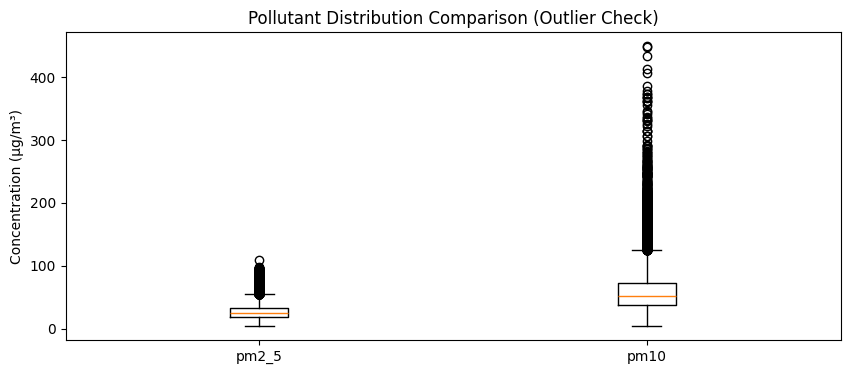

In [38]:
plt.figure(figsize=(10,4))

plt.boxplot([df[col].dropna() for col in pollutant_cols],
            labels=pollutant_cols)

plt.title("Pollutant Distribution Comparison (Outlier Check)")
plt.ylabel("Concentration (µg/m³)")

plt.show()

## In terms of data quality and stability, PM2.5 is “better” because it is Easier to model and interpret. PM10, on the other hand, is more volatile 

In [39]:
# Check Extreme Spikes (Using IQR Method)

In [40]:
outlier_summary = {}

pm2_5 Outliers Count: 784
pm10 Outliers Count: 926


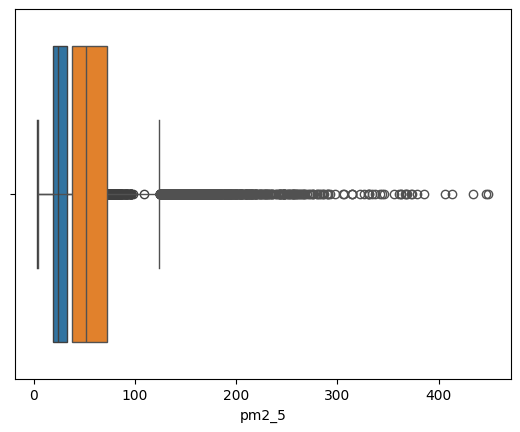

In [75]:
for col in pollutant_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        
        outlier_summary[col] = len(outliers)
        print(f"{col} Outliers Count:", len(outliers))
        sns.boxplot(x=df[col])

In [42]:
#  Compare Spikes With Timeline

In [43]:
if "time" in df.columns:
    for col in pollutant_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        upper = Q3 + 1.5 * IQR
        
        spikes = df[df[col] > upper][["time", col]].sort_values(col, ascending=False)
        
        print(f"\nTop Spikes Timeline for {col}:")
        print(spikes.head(10))


Top Spikes Timeline for pm2_5:
                     time  pm2_5
8169  2025-01-04 09:00:00  108.7
8168  2025-01-04 08:00:00   98.0
15384 2025-11-01 00:00:00   96.4
16893 2026-01-02 21:00:00   95.9
15385 2025-11-01 01:00:00   95.7
15381 2025-10-31 21:00:00   95.7
8470  2025-01-16 22:00:00   95.7
10700 2025-04-19 20:00:00   95.7
15383 2025-10-31 23:00:00   95.5
15382 2025-10-31 22:00:00   95.0

Top Spikes Timeline for pm10:
                     time   pm10
2964  2024-06-01 12:00:00  448.9
2965  2024-06-01 13:00:00  447.0
2966  2024-06-01 14:00:00  434.0
2967  2024-06-01 15:00:00  413.5
2963  2024-06-01 11:00:00  406.1
11701 2025-05-31 13:00:00  385.6
11700 2025-05-31 12:00:00  378.1
2968  2024-06-01 16:00:00  373.5
11748 2025-06-02 12:00:00  372.5
10701 2025-04-19 21:00:00  368.8


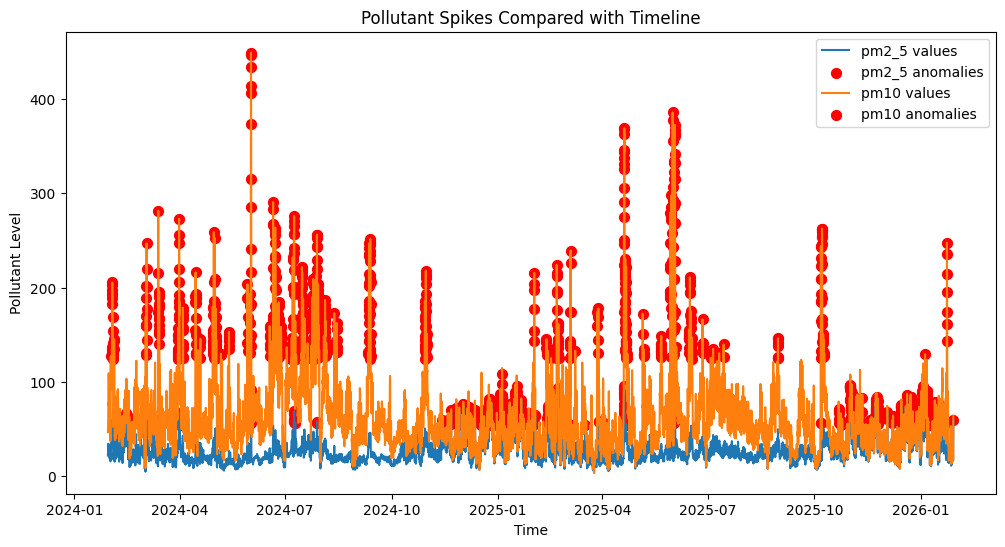

In [81]:
plt.figure(figsize=(12,6)) 
for col in pollutant_cols: 
    if col in df.columns:
    # Calculate IQR thresholds
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
# Plot full time series
        plt.plot(df['time'], df[col], label=f"{col} values")
# Highlight anomalies
        spikes = df[(df[col] < lower) | (df[col] > upper)]
        plt.scatter(spikes['time'], spikes[col], color='red', marker='o', s=50, label=f"{col} anomalies")
plt.xlabel("Time")
plt.ylabel("Pollutant Level")
plt.title("Pollutant Spikes Compared with Timeline")
plt.legend()
plt.show()

## the timeline comparison clearly highlights multiple pollutant spikes (PM2.5 and PM10) as red-marked anomalies occurring at distinct points in time

In [44]:
 #Document Outlier Observations (Auto Summary)

In [45]:
print("\n===== Outlier Documentation Summary =====")
for col, count in outlier_summary.items():
    print(f"{col}: {count} potential outliers detected (IQR Method)")


===== Outlier Documentation Summary =====
pm2_5: 784 potential outliers detected (IQR Method)
pm10: 926 potential outliers detected (IQR Method)


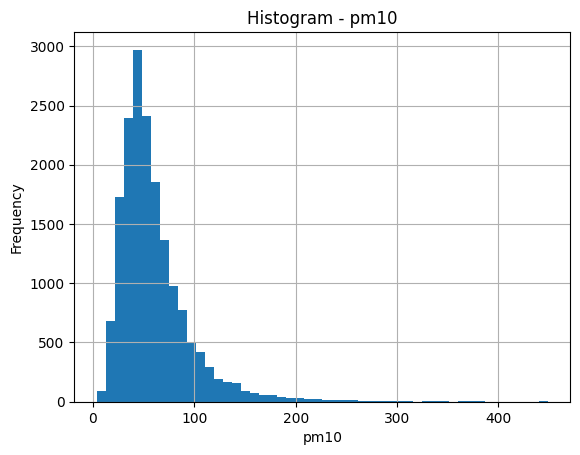

In [46]:
 ##. Frequency of pm2.5 and pm 10
plt.figure()
df[col].hist(bins=50)
plt.title(f"Histogram - {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

In [47]:
#Summary Statistics
print("\nSummary Statistics:")
print(df[col].describe())


Summary Statistics:
count    17520.000000
mean        60.379715
std         36.850146
min          3.900000
25%         37.800000
50%         51.500000
75%         72.400000
max        448.900000
Name: pm10, dtype: float64


In [48]:
# . Range (Min → Max)
print("\nRange:")
print(f"Min: {df[col].min()}")
print(f"Max: {df[col].max()}")


Range:
Min: 3.9
Max: 448.9


In [49]:
#Skewness
skew_val = df[col].skew()
print("\nSkewness:", skew_val)

if skew_val > 1:
    print(" Highly Right Skewed")
elif skew_val < -1:
    print(" Highly Left Skewed")
else:
    print(" Fairly Symmetric / Moderate Skew")


Skewness: 2.6543003745808007
 Highly Right Skewed


In [82]:
df[f"{col}_log"] = np.log1p(df[col])

In [83]:
df[f"{col}_sqrt"] = np.sqrt(df[col])

In [50]:
target_col = "pm2_5" 

In [87]:
pt = PowerTransformer(method='yeo-johnson')
df[f"{col}_transformed"] = pt.fit_transform(df[[col]])

In [89]:
df[f"{col}_log"] = np.log1p(df[col]) # Check skewness again 
skew_val = df[f"{col}_log"].skew()
print("Skewness after log transform:", skew_val)

Skewness after log transform: 0.15623189421462885


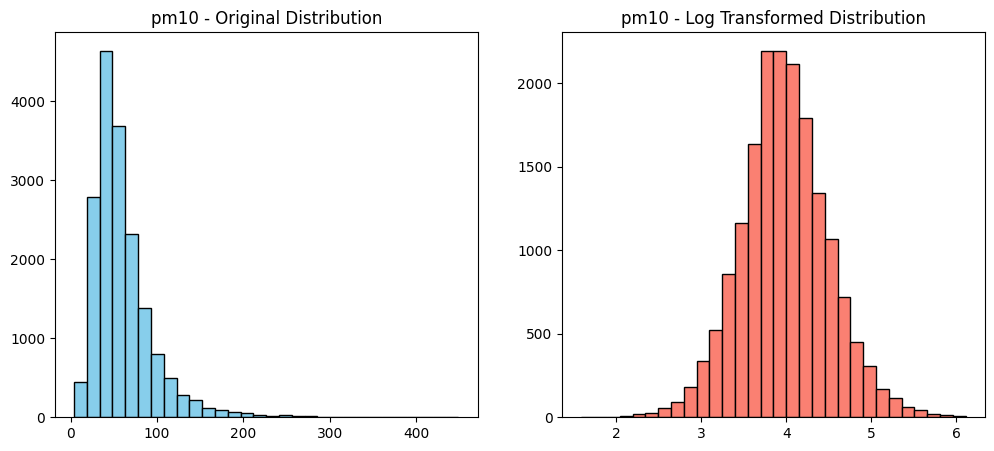

In [90]:
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
plt.title(f"{col} - Original Distribution")

# Transformed
plt.subplot(1,2,2)
plt.hist(df[f"{col}_log"], bins=30, color='salmon', edgecolor='black')
plt.title(f"{col} - Log Transformed Distribution")

plt.show()


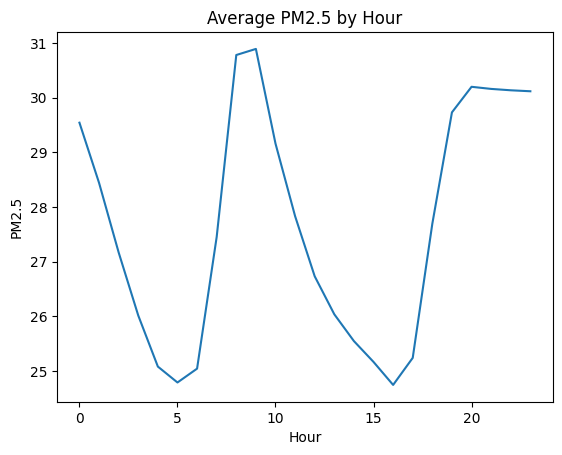

In [51]:
hourly_avg = df.groupby("hour")[target_col].mean()
plt.figure()
hourly_avg.plot()
plt.title("Average PM2.5 by Hour")
plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.show()

## The graph shows that PM2.5 concentrations dip around hour 5 and peak around hour 10, highlighting a hourly fluctuation

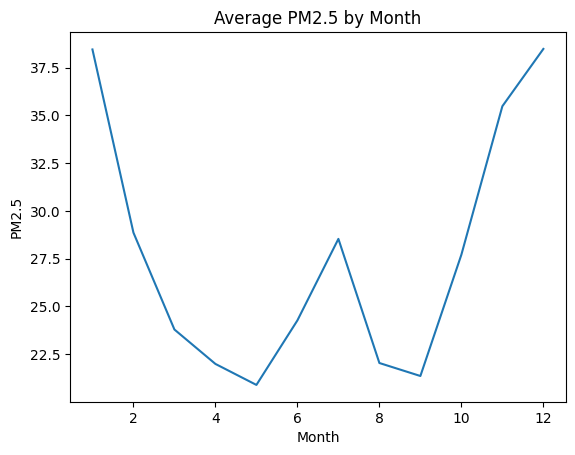

In [52]:
# Monthly Pattern
monthly_avg = df.groupby("month")[target_col].mean()
plt.figure()
monthly_avg.plot()
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.show()

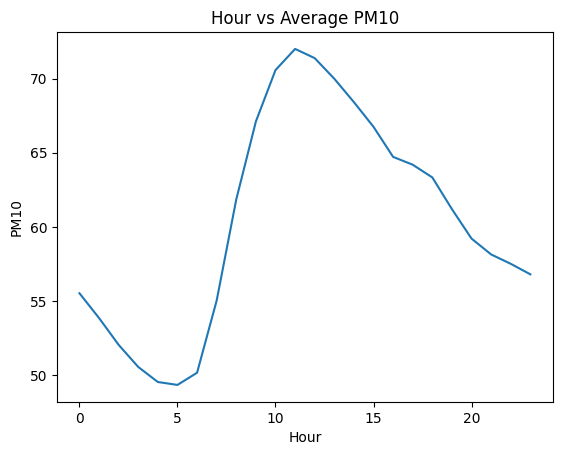

In [55]:
#  Hour vs PM10 Plot
if "pm10" in df.columns and "hour" in df.columns:
    hourly_pm10 = df.groupby("hour")["pm10"].mean()
    
    plt.figure()
    hourly_pm10.plot()
    plt.title("Hour vs Average PM10")
    plt.xlabel("Hour")
    plt.ylabel("PM10")
    plt.show()

In [56]:
corr_cols = [
    "pm2_5", "pm10",
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m"
] #Correlation Heatmap

In [57]:
existing_cols = [c for c in corr_cols if c in df.columns]

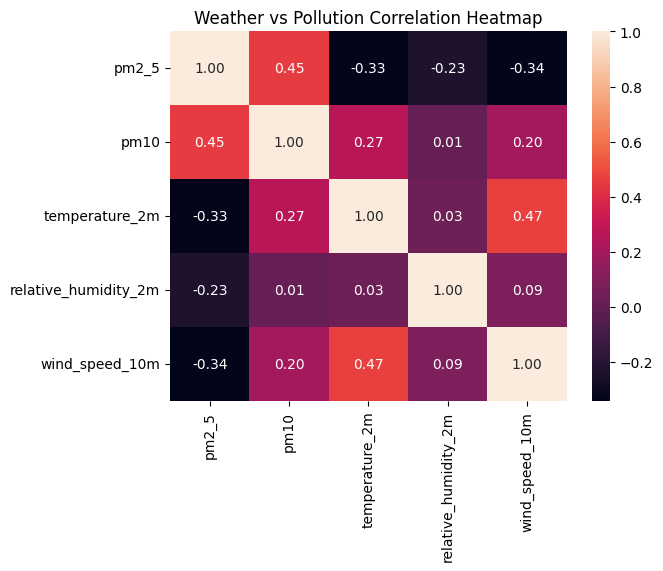

In [58]:
plt.figure()
sns.heatmap(df[existing_cols].corr(), annot=True, fmt=".2f")
plt.title("Weather vs Pollution Correlation Heatmap")
plt.show()

## The heatmap shows that PM2.5 decreases with higher temperature, humidity, and wind (dispersion effect), while PM10 slightly rises with temperature and wind (dust resuspension)

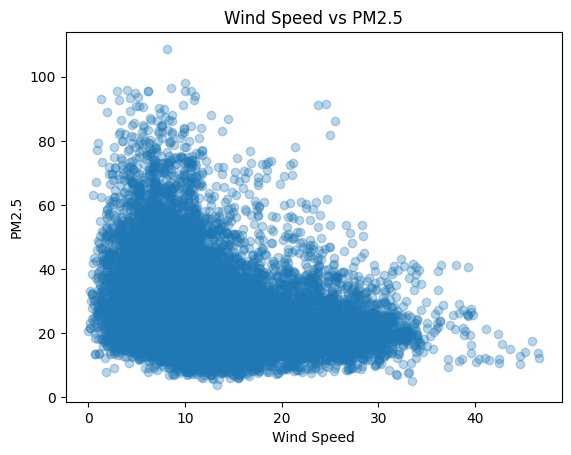

In [59]:
#Wind vs PM Scatter
plt.figure()
plt.scatter(df["wind_speed_10m"], df["pm2_5"], alpha=0.3)
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.title("Wind Speed vs PM2.5")
plt.show()

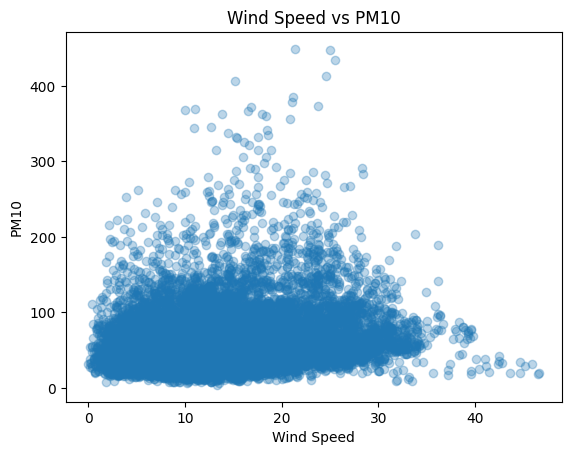

In [60]:
plt.figure()
plt.scatter(df["wind_speed_10m"], df["pm10"], alpha=0.3)
plt.xlabel("Wind Speed")
plt.ylabel("PM10")
plt.title("Wind Speed vs PM10")
plt.show()

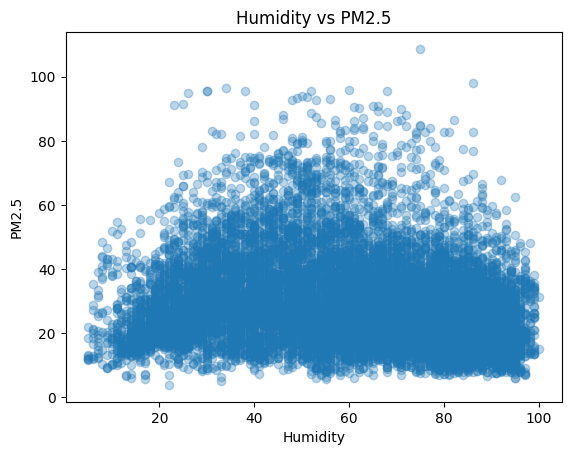

In [61]:
#Humidity vs PM Scatter
plt.figure()
plt.scatter(df["relative_humidity_2m"], df["pm2_5"], alpha=0.3)
plt.xlabel("Humidity")
plt.ylabel("PM2.5")
plt.title("Humidity vs PM2.5")
plt.show()

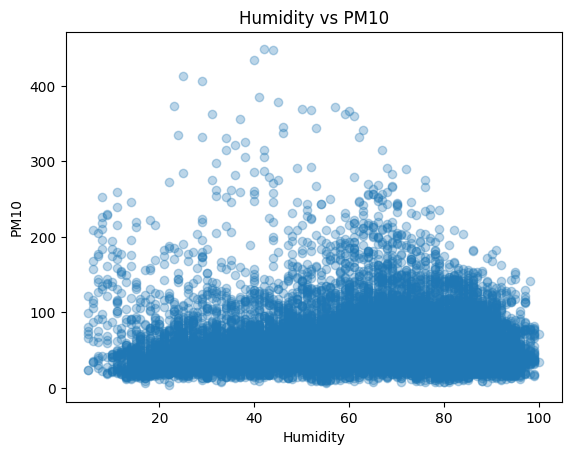

In [62]:
plt.figure()
plt.scatter(df["relative_humidity_2m"], df["pm10"], alpha=0.3)
plt.xlabel("Humidity")
plt.ylabel("PM10")
plt.title("Humidity vs PM10")
plt.show()

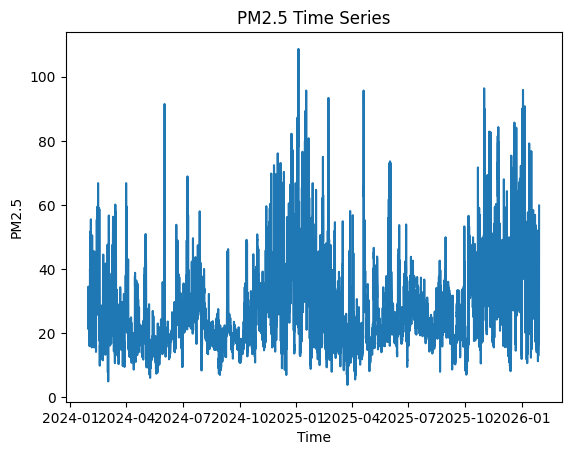

In [63]:
df = df.sort_values("time")

plt.figure()
plt.plot(df["time"], df["pm2_5"])
plt.title("PM2.5 Time Series")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

In [64]:
df = df.sort_values("time")

# Lag 1 Hour
df["pm2_5_lag1"] = df["pm2_5"].shift(1)

# Lag 24 Hours (Same hour previous day)
df["pm2_5_lag24"] = df["pm2_5"].shift(24)

✅ Lag Features Created


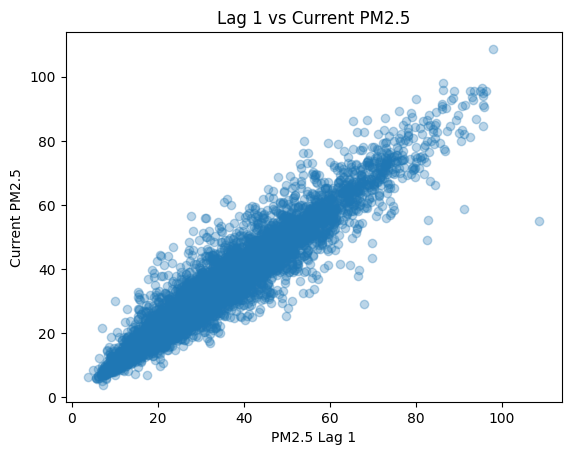

In [65]:
plt.figure()
plt.scatter(df["pm2_5_lag1"], df["pm2_5"], alpha=0.3)
plt.xlabel("PM2.5 Lag 1")
plt.ylabel("Current PM2.5")
plt.title("Lag 1 vs Current PM2.5")
plt.show()

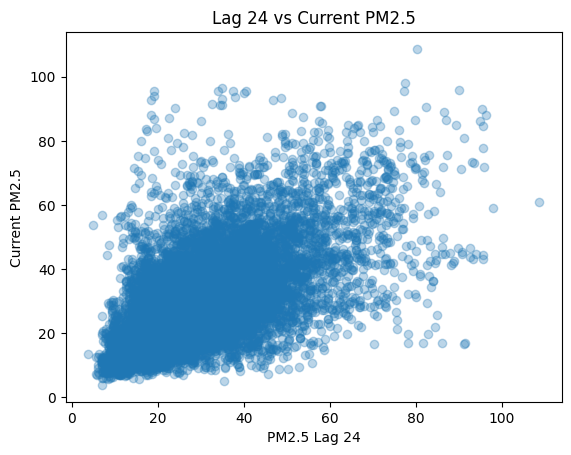

In [66]:
plt.figure()
plt.scatter(df["pm2_5_lag24"], df["pm2_5"], alpha=0.3)
plt.xlabel("PM2.5 Lag 24")
plt.ylabel("Current PM2.5")
plt.title("Lag 24 vs Current PM2.5")
plt.show()

 ## Pollution levels don’t always change instantly with weather  PM2.5 shows delayed responses (lagged effects), while PM10 reacts faster. 

In [67]:
if "pm2_5" in df.columns:
    print("Lag 1 Correlation:", df["pm2_5"].corr(df["pm2_5_lag1"]))
    print("Lag 24 Correlation:", df["pm2_5"].corr(df["pm2_5_lag24"]))

Lag 1 Correlation: 0.9657208699073233
Lag 24 Correlation: 0.6423207262040657


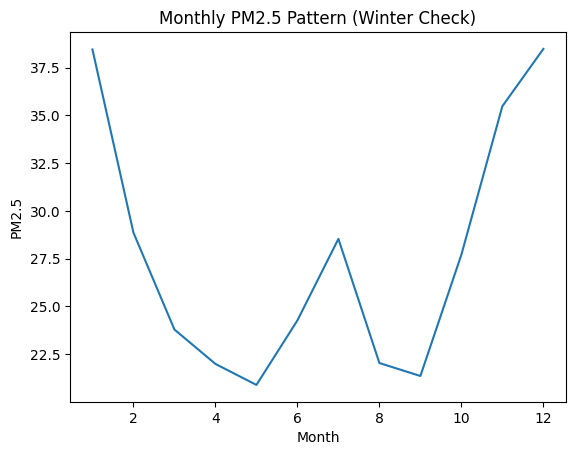

In [68]:
#Winter Pollution Increase Check

winter_df = df[df["month"].isin([12, 1, 2])]
monthly_pm25 = df.groupby("month")["pm2_5"].mean()

plt.figure()
monthly_pm25.plot()
plt.title("Monthly PM2.5 Pattern (Winter Check)")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.show()

In [91]:
# Night vs Day Pollution Pattern
# Night = 0–6, Day = 7–18, Evening = 19–23

def day_period(hour):
    if hour <= 6:
        return "Night"
    elif hour <= 18:
        return "Day"
    else:
        return "Evening"

In [70]:
df["day_period"] = df["hour"].apply(day_period)

In [71]:
period_pm25 = df.groupby("day_period")["pm2_5"].mean()

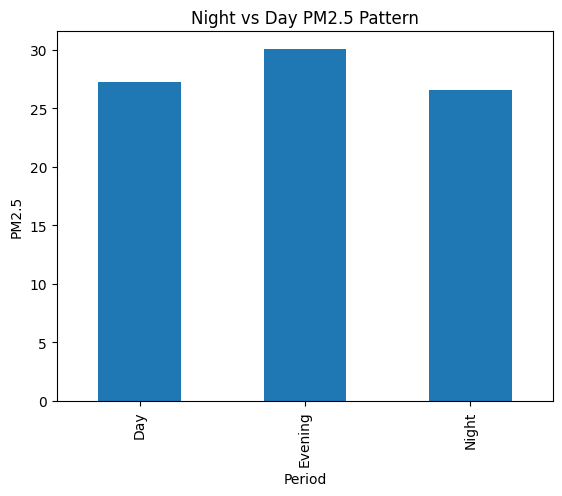

In [72]:
plt.figure()
period_pm25.plot(kind="bar")
plt.title("Night vs Day PM2.5 Pattern")
plt.xlabel("Period")
plt.ylabel("PM2.5")
plt.show()

## the Graph show the the pm2.5 are increase in Evening, while the night and Day are mostly equal

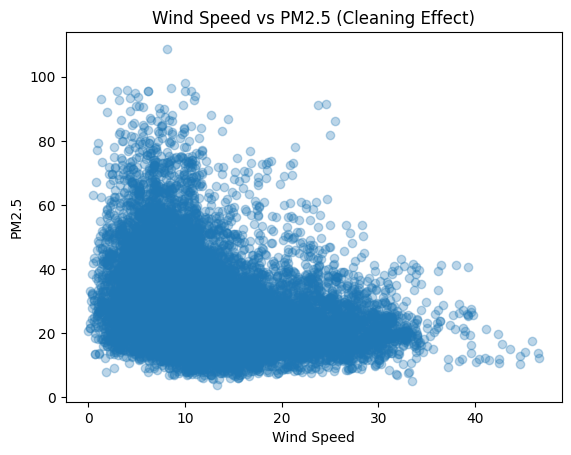

In [92]:
#Wind Cleaning Effect

plt.figure()
plt.scatter(df["wind_speed_10m"], df["pm2_5"], alpha=0.3)
plt.title("Wind Speed vs PM2.5 (Cleaning Effect)")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.show()

In [94]:
# Sudden Dust Spike Events
# (Top Extreme PM10 Events Timeline)


top_pm10_spikes = df.sort_values("pm10", ascending=False)[["time", "pm10"]].head(20)
print("\nTop PM10 Dust Spike Events:")
print(top_pm10_spikes)


Top PM10 Dust Spike Events:
                     time   pm10
2964  2024-06-01 12:00:00  448.9
2965  2024-06-01 13:00:00  447.0
2966  2024-06-01 14:00:00  434.0
2967  2024-06-01 15:00:00  413.5
2963  2024-06-01 11:00:00  406.1
11701 2025-05-31 13:00:00  385.6
11700 2025-05-31 12:00:00  378.1
2968  2024-06-01 16:00:00  373.5
11748 2025-06-02 12:00:00  372.5
10701 2025-04-19 21:00:00  368.8
10700 2025-04-19 20:00:00  367.9
11747 2025-06-02 11:00:00  366.9
11749 2025-06-02 13:00:00  362.3
10697 2025-04-19 17:00:00  362.3
11750 2025-06-02 14:00:00  360.4
11702 2025-05-31 14:00:00  355.8
10698 2025-04-19 18:00:00  345.5
10699 2025-04-19 19:00:00  343.7
11751 2025-06-02 15:00:00  341.8
10702 2025-04-19 22:00:00  337.1


## The table highlights severe PM10 dust spikes, with sustained events around June 2024 and May–June 2025, showing that coarse particulate pollution tends to surge in midday blocks, likely due to dust storms or strong winds.